# Runs Eval Training Curves

Plots training return and success-rate curves from `runs_eval/`. Each subplot is one environment and each line is the five-seed mean for one algorithm.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Robust project-root detection whether the notebook is run from repo root or notebooks/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / "runs_eval").exists() else CWD.parent
RUNS_ROOT = PROJECT_ROOT / "runs_eval"
FIG_DIR = PROJECT_ROOT / "figures" / "runs_eval"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert RUNS_ROOT.exists(), f"Missing {RUNS_ROOT}"
RUNS_ROOT

PosixPath('/Users/charithapalika/Desktop/Personal Projects/PPO_CF/runs_eval')

In [2]:
ENVS = [
    ("redbluedoors6x6", "RedBlueDoors 6x6"),
    ("keycorridors3r2", "KeyCorridor S3R2"),
    ("keycorridors3r3", "KeyCorridor S3R3"),
    ("doorkey6x6", "DoorKey 6x6"),
    ("unlockpickup", "UnlockPickup"),
]

ALGOS = [
    ("gae", "PPO"),
    ("cf", "PPO-CF"),
    ("queried_b0p75", "Queried perturb"),
    ("distill_b0p75", "Distilled beta"),
    ("uncertainty_b0p75", "Uncertainty distilled"),
    ("active_b0p75", "Active distilled"),
]

# High-contrast, colorblind-safer palette. Keep labels fixed across all envs/figures.
COLORS = {
    "PPO": "#0072B2",                  # blue
    "PPO-CF": "#D55E00",               # vermillion
    "Queried perturb": "#009E73",      # bluish green
    "Distilled beta": "#CC79A7",       # reddish purple
    "Uncertainty distilled": "#E69F00",# orange
    "Active distilled": "#000000",     # black
}

SEEDS = list(range(5))
VALUE_COLS = ["mean_return_100", "success_rate_100"]

In [3]:
def run_dir(env_key: str, algo_key: str) -> Path:
    return RUNS_ROOT / f"cfg_{env_key}_{algo_key}"

def load_scalars() -> pd.DataFrame:
    frames = []
    missing = []
    for env_key, env_label in ENVS:
        for algo_key, algo_label in ALGOS:
            base = run_dir(env_key, algo_key)
            for seed in SEEDS:
                path = base / f"seed_{seed}" / "scalars.csv"
                if not path.exists():
                    missing.append(str(path.relative_to(PROJECT_ROOT)))
                    continue
                df = pd.read_csv(path)
                needed = {"global_step", *VALUE_COLS}
                absent = needed - set(df.columns)
                if absent:
                    raise ValueError(f"{path} missing columns {sorted(absent)}")
                df = df[["global_step", *VALUE_COLS]].copy()
                df["global_step"] = pd.to_numeric(df["global_step"], errors="coerce")
                for col in VALUE_COLS:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
                df = df.dropna(subset=["global_step"]).sort_values("global_step")
                df["env"] = env_key
                df["env_label"] = env_label
                df["algo"] = algo_key
                df["algo_label"] = algo_label
                df["seed"] = seed
                frames.append(df)
    if missing:
        raise FileNotFoundError("Missing scalar files:\n" + "\n".join(missing[:50]))
    out = pd.concat(frames, ignore_index=True)
    return out

scalars = load_scalars()
summary = (scalars.groupby(["env_label", "algo_label", "seed"])
           .agg(max_step=("global_step", "max"), rows=("global_step", "size"),
                final_return=("mean_return_100", "last"), final_success=("success_rate_100", "last"))
           .reset_index())
print(f"Loaded {len(summary)} seed curves from {RUNS_ROOT.relative_to(PROJECT_ROOT)}")
display(summary.head())
assert len(summary) == len(ENVS) * len(ALGOS) * len(SEEDS), len(summary)

Loaded 150 seed curves from runs_eval


,env_label,algo_label,seed,max_step,rows,final_return,final_success
0,DoorKey 6x6,Active distilled,0,749568,183,0.959900,1.0
1,DoorKey 6x6,Active distilled,1,749568,183,0.901100,1.0
2,DoorKey 6x6,Active distilled,2,749568,183,0.949575,1.0
3,DoorKey 6x6,Active distilled,3,749568,183,0.960125,1.0
4,DoorKey 6x6,Active distilled,4,749568,183,0.957750,1.0


In [4]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "figure.titlesize": 22,
    "figure.titleweight": "bold",
    "axes.grid": False,
    "lines.linewidth": 2.8,
})

def aggregate_curve(df: pd.DataFrame, value_col: str, n_grid: int = 250):
    max_step = float(df["global_step"].max())
    grid = np.linspace(0.0, max_step, n_grid)
    ys = []
    for _, seed_df in df.groupby("seed"):
        seed_df = seed_df.sort_values("global_step")
        x = seed_df["global_step"].to_numpy(dtype=float)
        y = seed_df[value_col].to_numpy(dtype=float)
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if len(x) == 0:
            continue
        unique_x, idx = np.unique(x, return_index=True)
        unique_y = y[idx]
        ys.append(np.interp(grid, unique_x, unique_y, left=unique_y[0], right=unique_y[-1]))
    if not ys:
        return grid, np.full_like(grid, np.nan), np.full_like(grid, np.nan)
    arr = np.vstack(ys)
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(mean)
    return grid, mean, sem

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", width=1.4, length=5)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(1.4)

def plot_metric(value_col: str, ylabel: str, title: str, filename_stem: str, ylim=None):
    fig, axes = plt.subplots(1, len(ENVS), figsize=(24, 4.8), sharey=False, constrained_layout=False)
    handles = {}
    for ax, (env_key, env_label) in zip(axes, ENVS):
        env_df = scalars[scalars["env"] == env_key]
        for algo_key, algo_label in ALGOS:
            sub = env_df[env_df["algo"] == algo_key]
            grid, mean, sem = aggregate_curve(sub, value_col)
            line, = ax.plot(grid / 1_000_000.0, mean, color=COLORS[algo_label], label=algo_label, linestyle="-")
            handles[algo_label] = line
        ax.set_title(env_label, fontweight="bold")
        ax.set_xlabel("Frames (M)", fontweight="bold")
        if ylim is not None:
            ax.set_ylim(*ylim)
        style_axis(ax)
    axes[0].set_ylabel(ylabel, fontweight="bold")
    fig.suptitle(title, fontweight="bold", y=1.05)
    ordered_handles = [handles[label] for _, label in ALGOS]
    ordered_labels = [label for _, label in ALGOS]
    leg = fig.legend(ordered_handles, ordered_labels, loc="lower center", bbox_to_anchor=(0.5, -0.12),
                     ncol=3, frameon=False, handlelength=3.0, columnspacing=1.8)
    for text in leg.get_texts():
        text.set_fontweight("bold")
    fig.tight_layout(rect=(0, 0.12, 1, 0.96))
    png = FIG_DIR / f"{filename_stem}.png"
    pdf = FIG_DIR / f"{filename_stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return fig, png, pdf

figures/runs_eval/training_return_mean100.png
figures/runs_eval/training_return_mean100.pdf


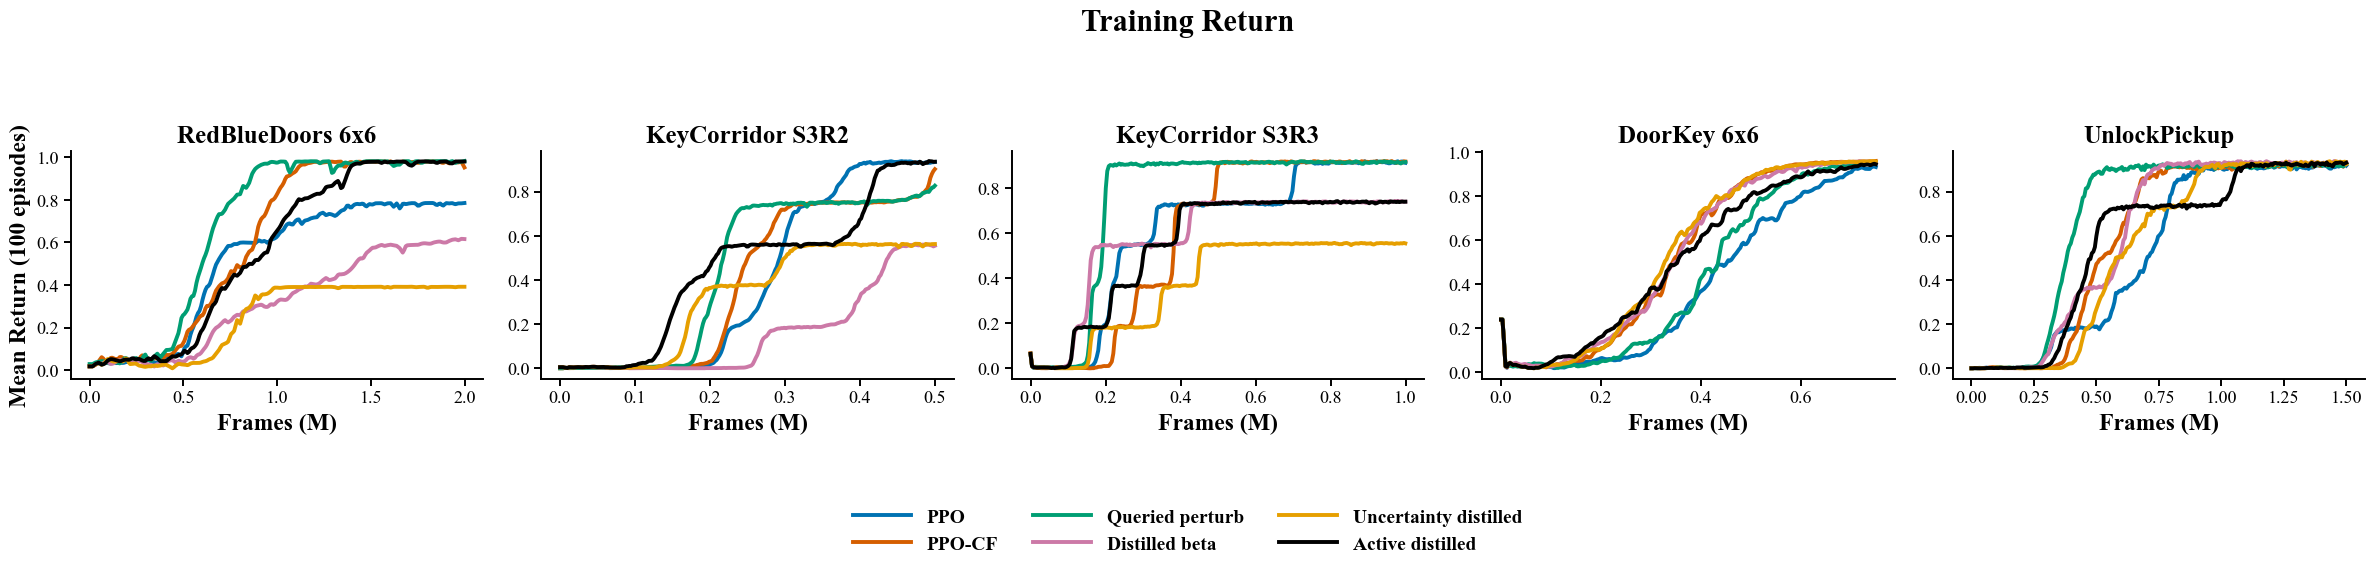

In [5]:
return_fig, return_png, return_pdf = plot_metric(
    "mean_return_100",
    ylabel="Mean Return (100 episodes)",
    title="Training Return",
    filename_stem="training_return_mean100",
)
print(return_png.relative_to(PROJECT_ROOT))
print(return_pdf.relative_to(PROJECT_ROOT))

figures/runs_eval/training_success_mean100.png
figures/runs_eval/training_success_mean100.pdf


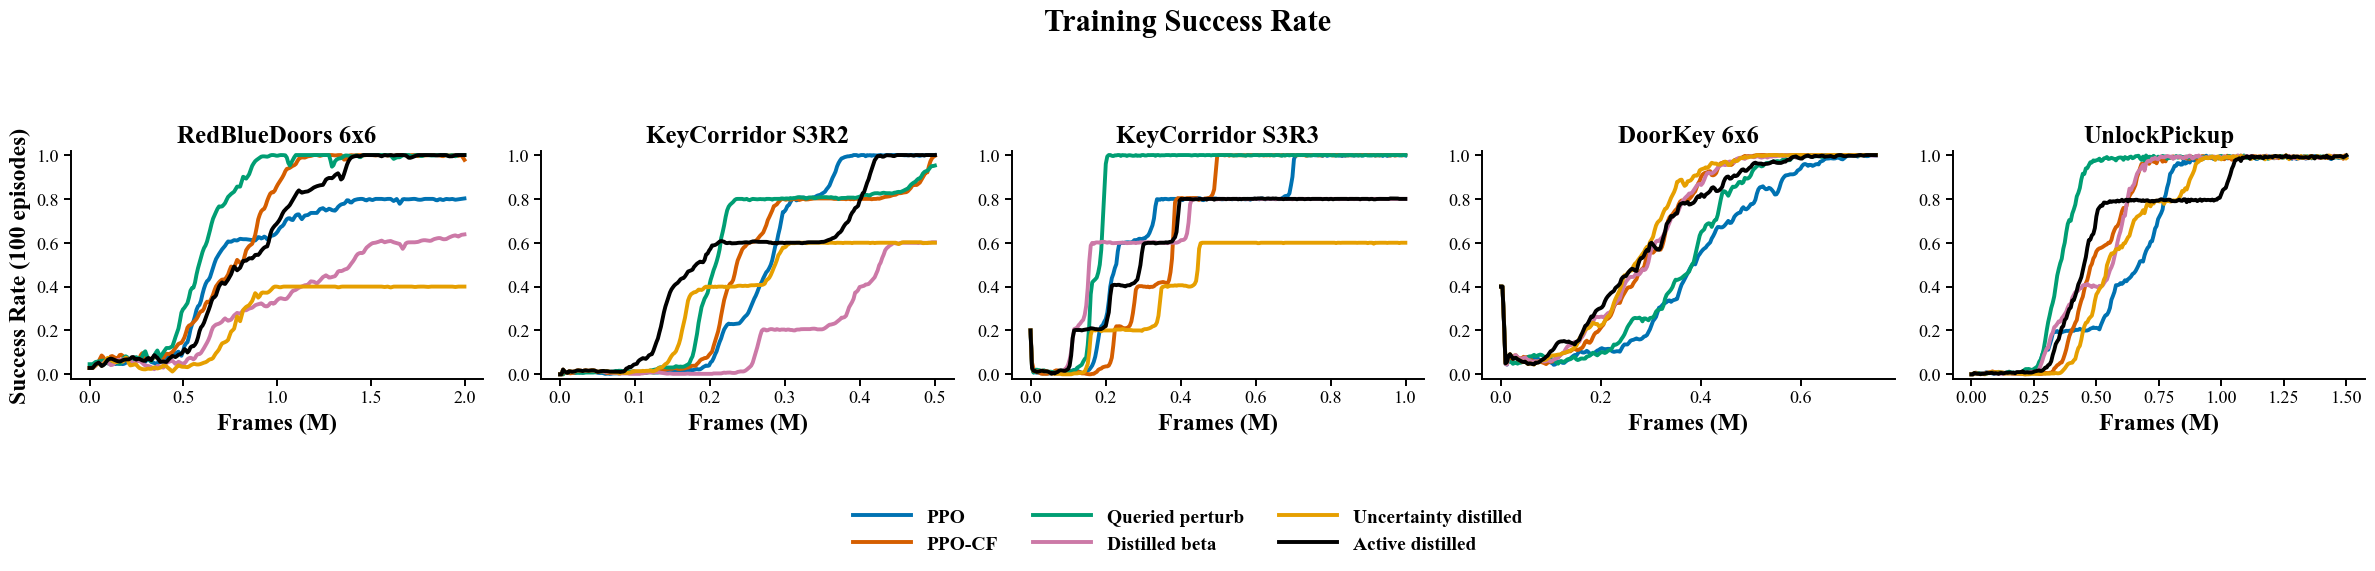

In [6]:
success_fig, success_png, success_pdf = plot_metric(
    "success_rate_100",
    ylabel="Success Rate (100 episodes)",
    title="Training Success Rate",
    filename_stem="training_success_mean100",
    ylim=(-0.02, 1.02),
)
print(success_png.relative_to(PROJECT_ROOT))
print(success_pdf.relative_to(PROJECT_ROOT))

In [7]:
final_table = (summary.groupby(["env_label", "algo_label"])
               .agg(seeds=("seed", "nunique"),
                    max_step_mean=("max_step", "mean"),
                    final_return_mean=("final_return", "mean"),
                    final_success_mean=("final_success", "mean"))
               .reset_index())
final_table["max_step_mean"] = final_table["max_step_mean"].round(0).astype(int)
final_table["final_return_mean"] = final_table["final_return_mean"].round(3)
final_table["final_success_mean"] = final_table["final_success_mean"].round(3)
display(final_table)

,env_label,algo_label,seeds,max_step_mean,final_return_mean,final_success_mean
0,DoorKey 6x6,Active distilled,5,749568,0.946,1.000
1,DoorKey 6x6,Distilled beta,5,749568,0.951,0.998
2,DoorKey 6x6,PPO,5,749568,0.933,0.998
3,DoorKey 6x6,PPO-CF,5,749568,0.960,1.000
4,DoorKey 6x6,Queried perturb,5,749568,0.953,1.000
5,DoorKey 6x6,Uncertainty distilled,5,749568,0.958,1.000
6,KeyCorridor S3R2,Active distilled,5,499712,0.935,1.000
7,KeyCorridor S3R2,Distilled beta,5,499712,0.555,0.602
8,KeyCorridor S3R2,PPO,5,499712,0.934,1.000
9,KeyCorridor S3R2,PPO-CF,5,499712,0.901,0.996


figures/runs_eval/training_return_mean100_focused.png
figures/runs_eval/training_return_mean100_focused.pdf
figures/runs_eval/training_success_mean100_focused.png
figures/runs_eval/training_success_mean100_focused.pdf


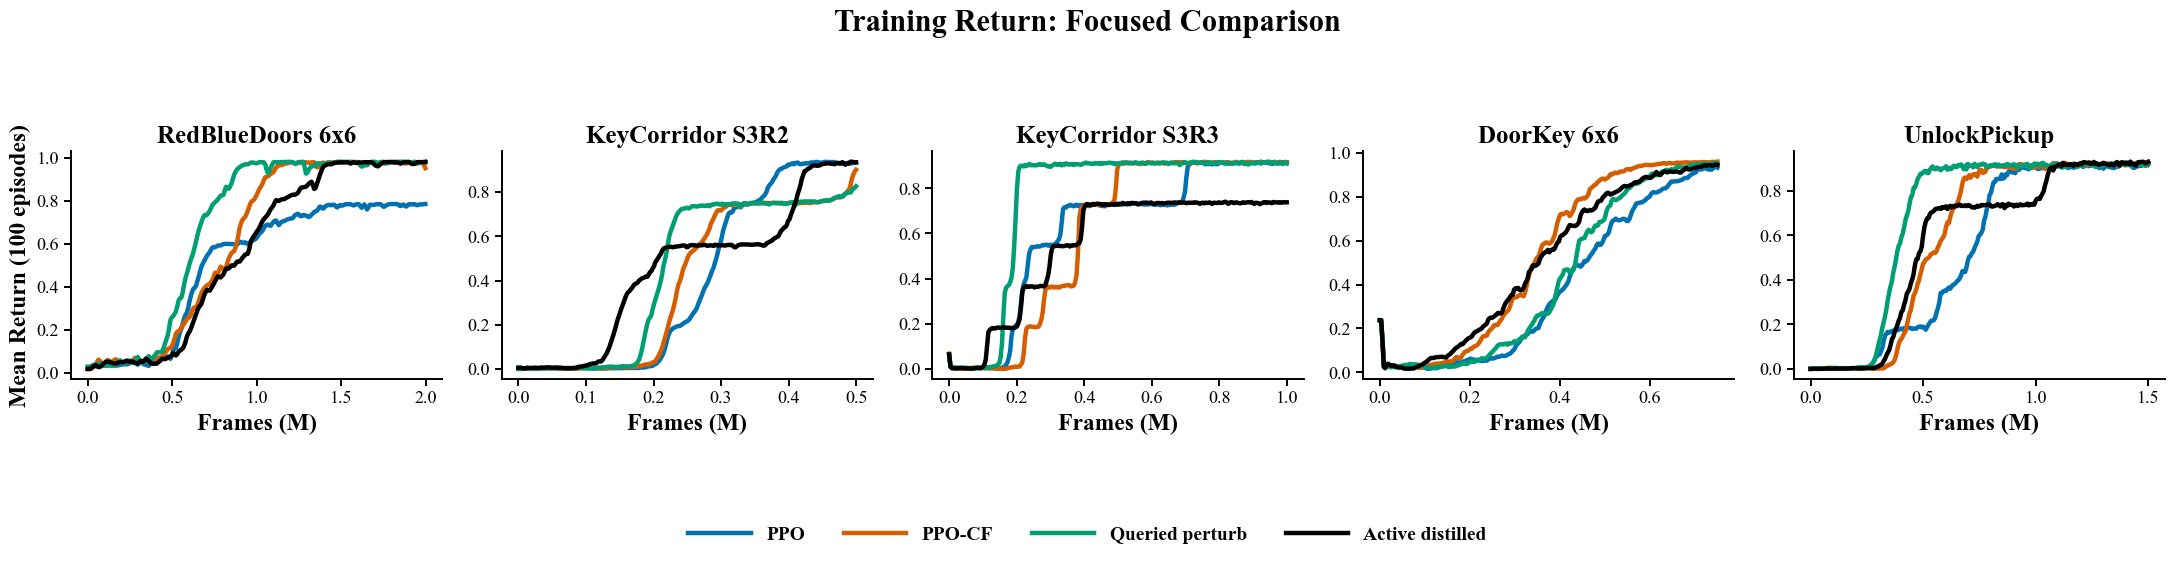

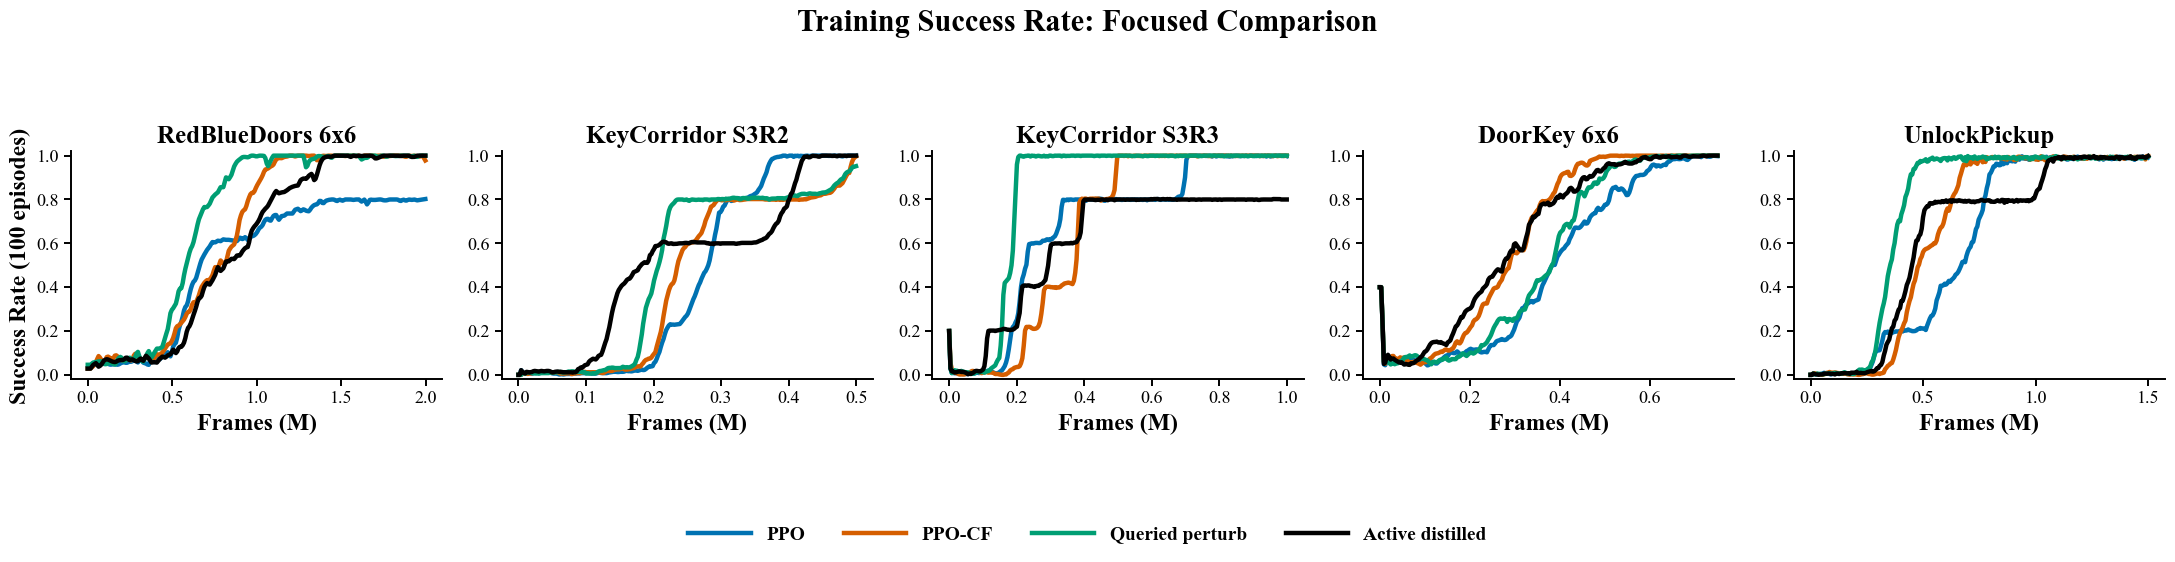

In [8]:
# Focused plot: PPO, PPO-CF, and the two strongest extra methods by mean success AUC.
# Selection from the full six-algo comparison above:
#   1. Queried perturb: best average success AUC across environments.
#   2. Active distilled: strongest remaining non-baseline/non-PPO-CF method overall.
FOCUSED_ALGOS = [
    ("gae", "PPO"),
    ("cf", "PPO-CF"),
    ("queried_b0p75", "Queried perturb"),
    ("active_b0p75", "Active distilled"),
]


def plot_metric_focused(value_col: str, ylabel: str, title: str, filename_stem: str, ylim=None):
    fig, axes = plt.subplots(1, len(ENVS), figsize=(22, 4.8), sharey=False, constrained_layout=False)
    handles = {}
    for ax, (env_key, env_label) in zip(axes, ENVS):
        env_df = scalars[scalars["env"] == env_key]
        for algo_key, algo_label in FOCUSED_ALGOS:
            sub = env_df[env_df["algo"] == algo_key]
            grid, mean, sem = aggregate_curve(sub, value_col)
            line, = ax.plot(
                grid / 1_000_000.0,
                mean,
                color=COLORS[algo_label],
                label=algo_label,
                linestyle="-",
                linewidth=3.2,
            )
            handles[algo_label] = line
        ax.set_title(env_label, fontweight="bold")
        ax.set_xlabel("Frames (M)", fontweight="bold")
        if ylim is not None:
            ax.set_ylim(*ylim)
        style_axis(ax)
    axes[0].set_ylabel(ylabel, fontweight="bold")
    fig.suptitle(title, fontweight="bold", y=1.05)
    ordered_handles = [handles[label] for _, label in FOCUSED_ALGOS]
    ordered_labels = [label for _, label in FOCUSED_ALGOS]
    leg = fig.legend(
        ordered_handles,
        ordered_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.10),
        ncol=4,
        frameon=False,
        handlelength=3.2,
        columnspacing=2.0,
    )
    for text in leg.get_texts():
        text.set_fontweight("bold")
    fig.tight_layout(rect=(0, 0.12, 1, 0.96))
    png = FIG_DIR / f"{filename_stem}.png"
    pdf = FIG_DIR / f"{filename_stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return fig, png, pdf


focused_return_fig, focused_return_png, focused_return_pdf = plot_metric_focused(
    "mean_return_100",
    ylabel="Mean Return (100 episodes)",
    title="Training Return: Focused Comparison",
    filename_stem="training_return_mean100_focused",
)
focused_success_fig, focused_success_png, focused_success_pdf = plot_metric_focused(
    "success_rate_100",
    ylabel="Success Rate (100 episodes)",
    title="Training Success Rate: Focused Comparison",
    filename_stem="training_success_mean100_focused",
    ylim=(-0.02, 1.02),
)

print(focused_return_png.relative_to(PROJECT_ROOT))
print(focused_return_pdf.relative_to(PROJECT_ROOT))
print(focused_success_png.relative_to(PROJECT_ROOT))
print(focused_success_pdf.relative_to(PROJECT_ROOT))

figures/runs_eval/training_return_mean100_ppo_vs_ppocf.png
figures/runs_eval/training_return_mean100_ppo_vs_ppocf.pdf
figures/runs_eval/training_return_mean100_ppo_vs_distilled_beta.png
figures/runs_eval/training_return_mean100_ppo_vs_distilled_beta.pdf
figures/runs_eval/training_return_mean100_ppo_vs_queried_perturb.png
figures/runs_eval/training_return_mean100_ppo_vs_queried_perturb.pdf
figures/runs_eval/training_return_mean100_ppo_vs_uncertainty_distilled.png
figures/runs_eval/training_return_mean100_ppo_vs_uncertainty_distilled.pdf


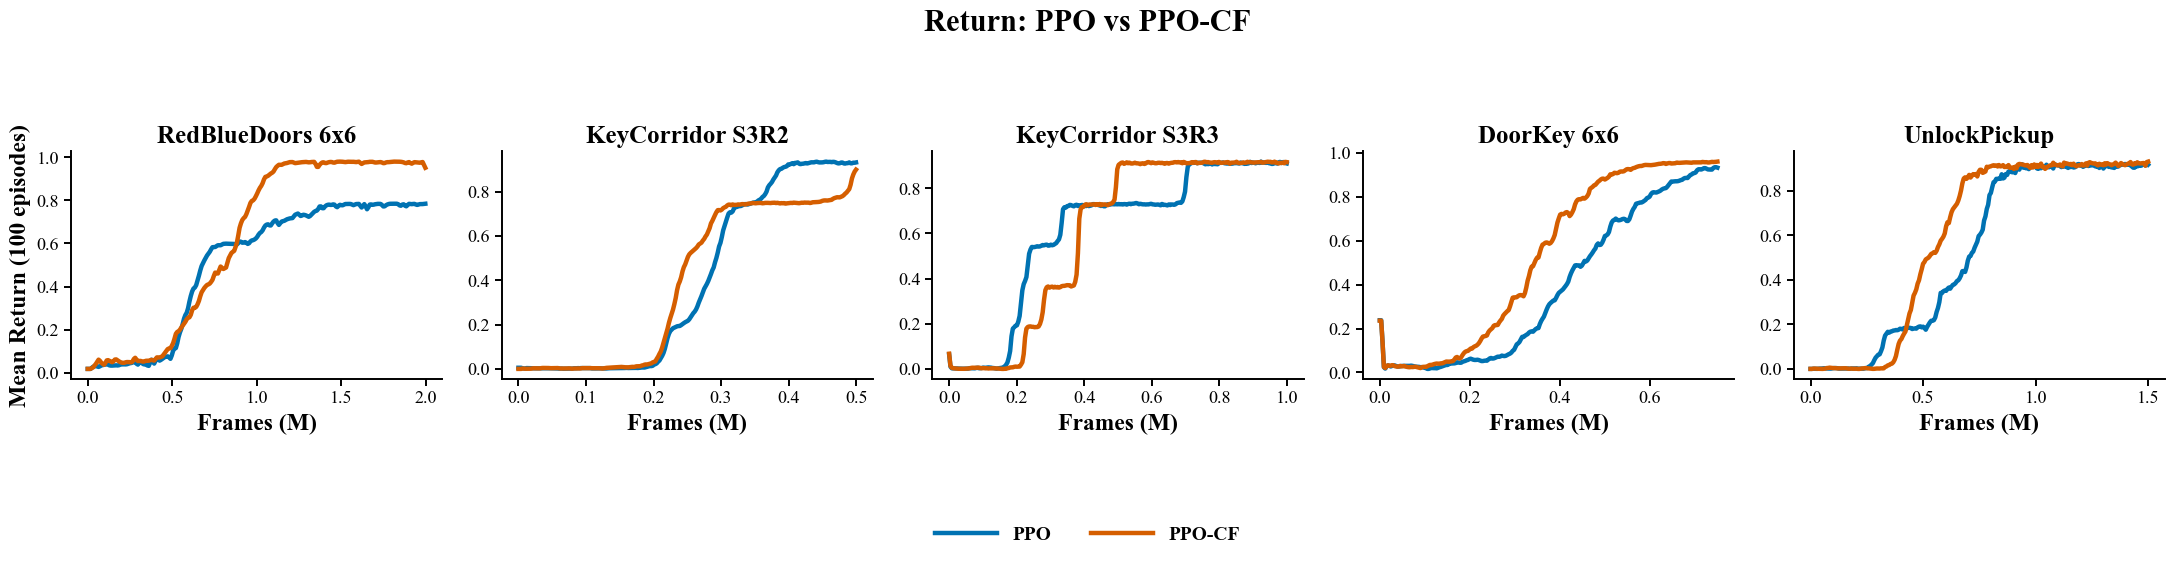

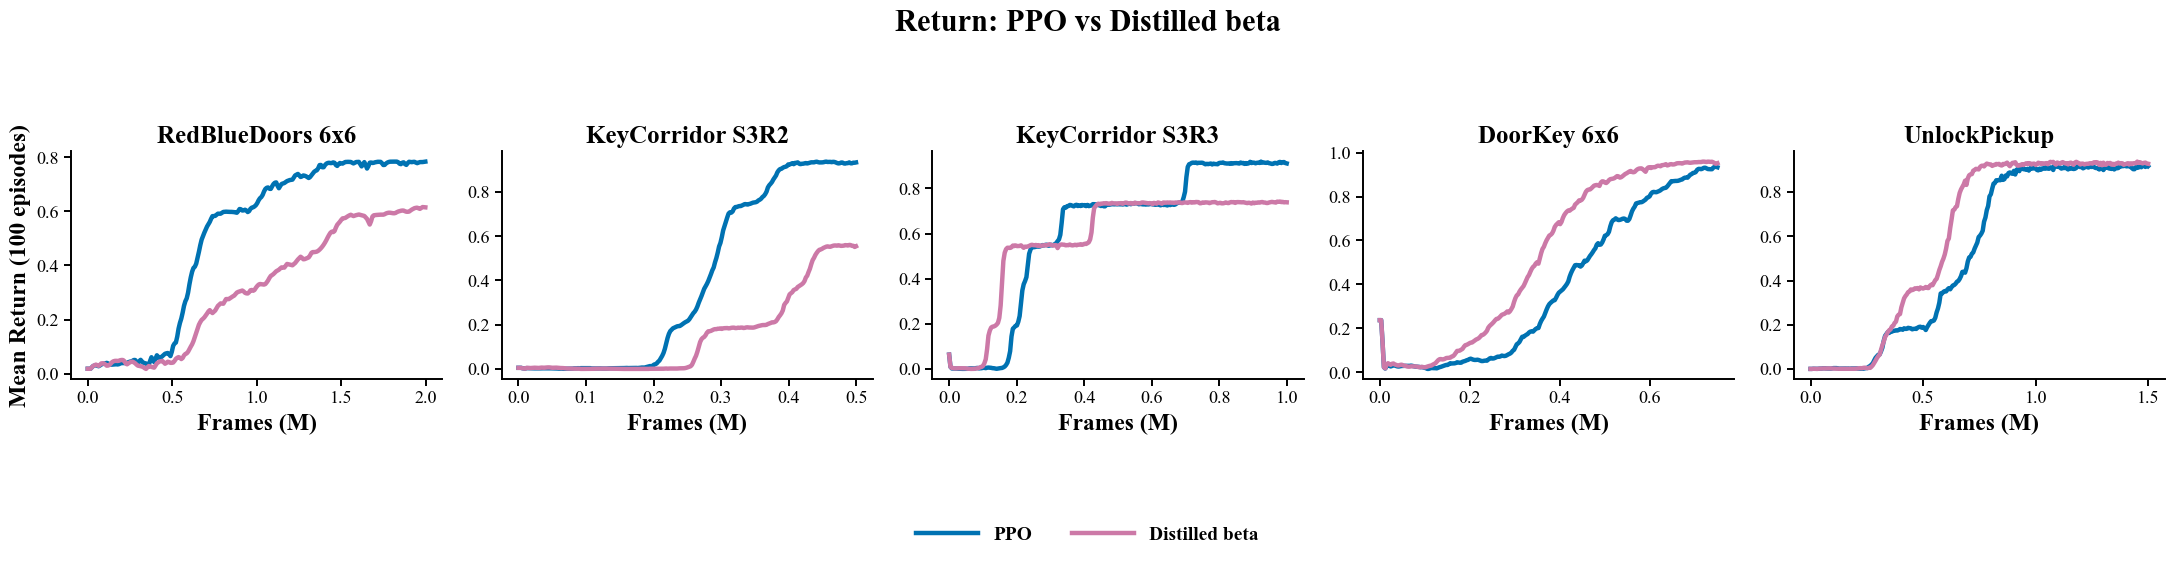

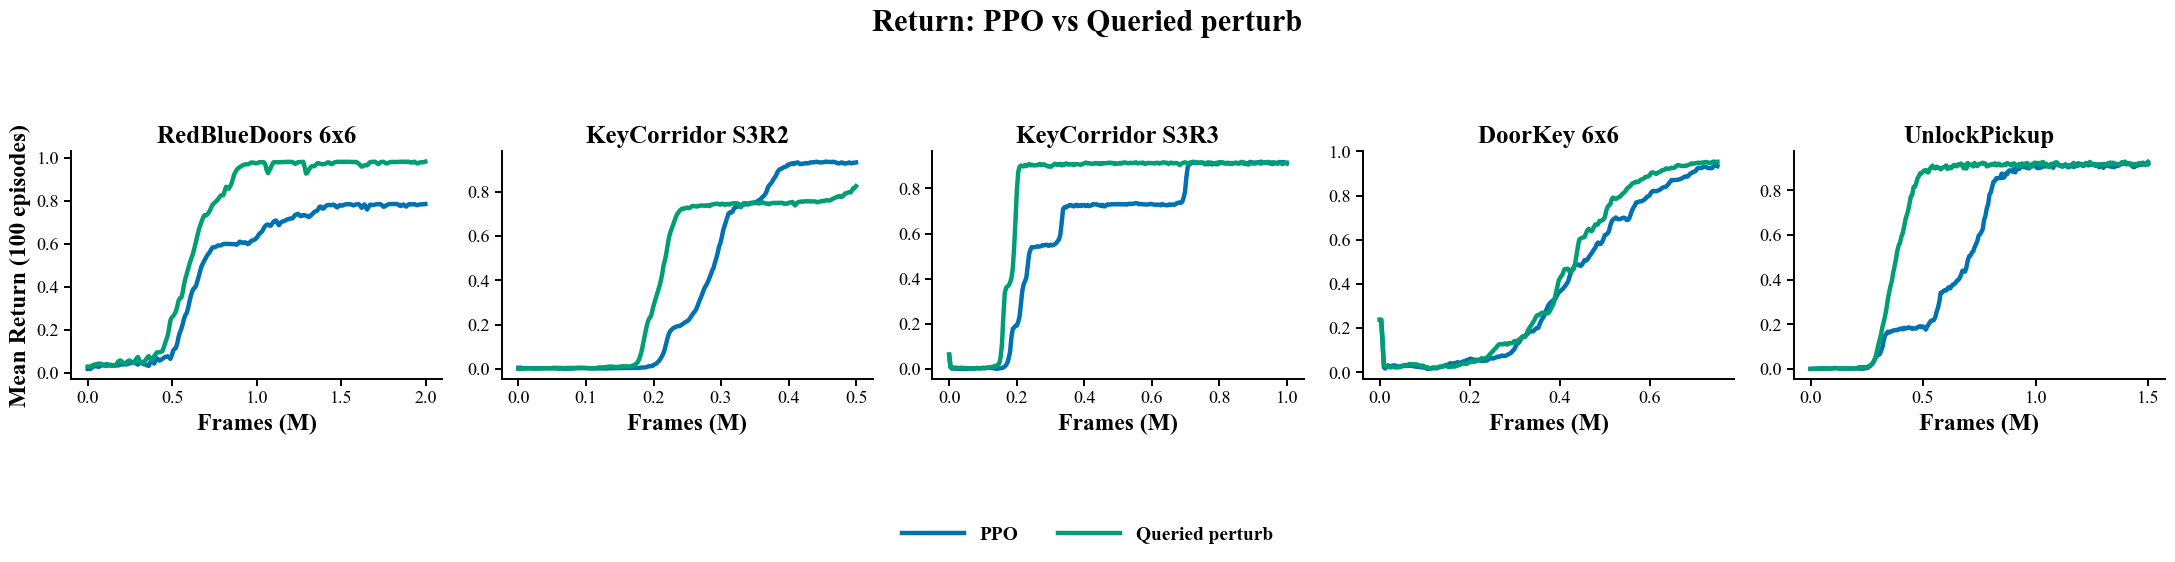

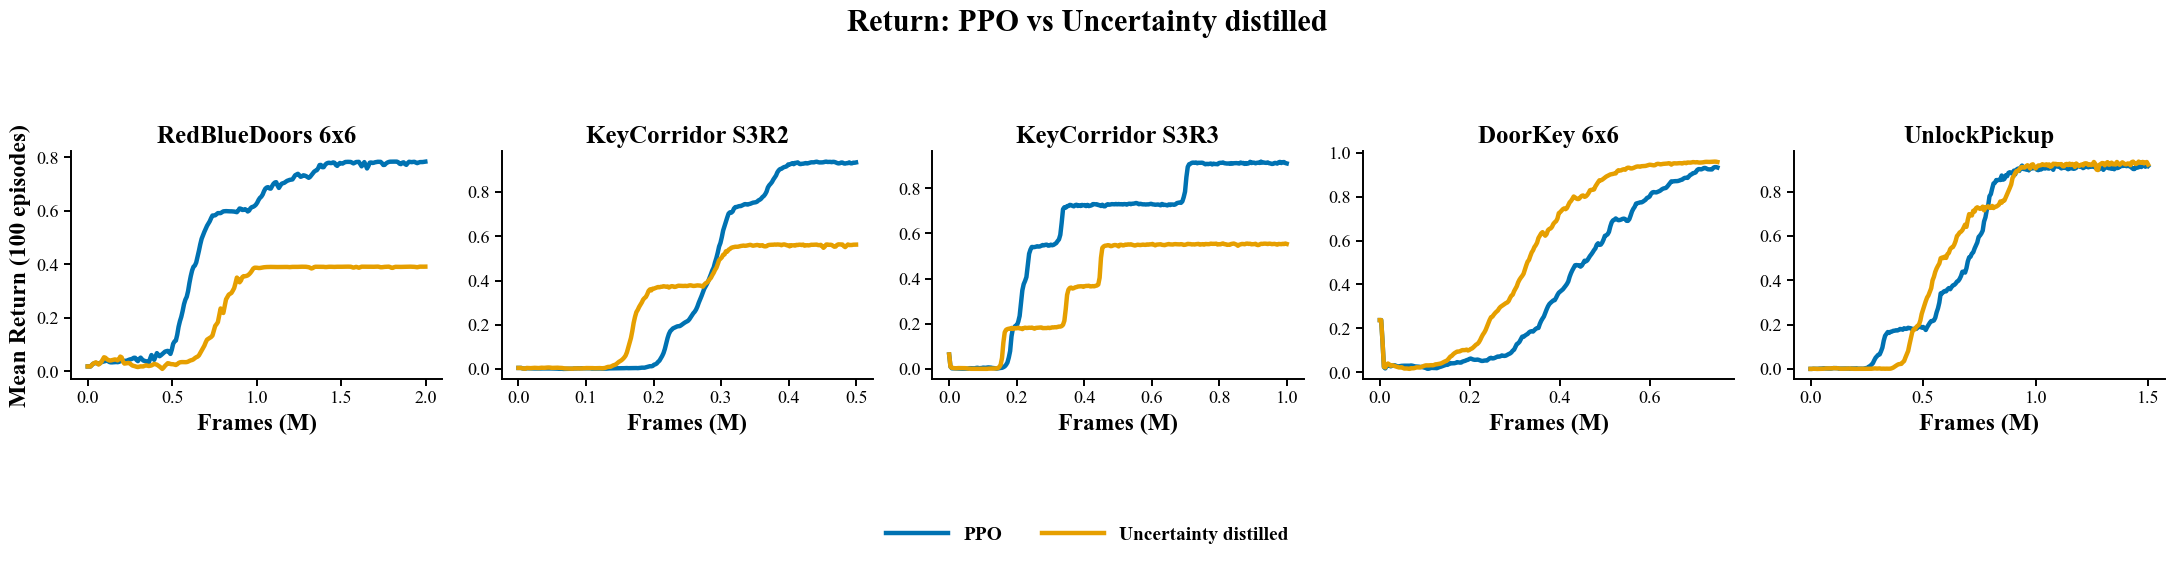

In [9]:
# Pairwise return comparisons against PPO.
PAIRWISE_COMPARISONS = [
    ("PPO vs PPO-CF", [("gae", "PPO"), ("cf", "PPO-CF")], "ppo_vs_ppocf"),
    ("PPO vs Distilled beta", [("gae", "PPO"), ("distill_b0p75", "Distilled beta")], "ppo_vs_distilled_beta"),
    ("PPO vs Queried perturb", [("gae", "PPO"), ("queried_b0p75", "Queried perturb")], "ppo_vs_queried_perturb"),
    ("PPO vs Uncertainty distilled", [("gae", "PPO"), ("uncertainty_b0p75", "Uncertainty distilled")], "ppo_vs_uncertainty_distilled"),
]

def plot_pairwise_metric(comparison, value_col, ylabel, metric_name, ylim=None):
    comparison_name, comparison_algos, filename_stem = comparison
    fig, axes = plt.subplots(1, len(ENVS), figsize=(22, 4.8), sharey=False, constrained_layout=False)
    handles = {}
    for ax, (env_key, env_label) in zip(axes, ENVS):
        env_df = scalars[scalars["env"] == env_key]
        for algo_key, algo_label in comparison_algos:
            grid, mean, sem = aggregate_curve(env_df[env_df["algo"] == algo_key], value_col)
            line, = ax.plot(grid / 1_000_000.0, mean, color=COLORS[algo_label], label=algo_label, linestyle="-", linewidth=3.2)
            handles[algo_label] = line
        ax.set_title(env_label, fontweight="bold")
        ax.set_xlabel("Frames (M)", fontweight="bold")
        if ylim is not None:
            ax.set_ylim(*ylim)
        style_axis(ax)
    axes[0].set_ylabel(ylabel, fontweight="bold")
    fig.suptitle(f"{metric_name}: {comparison_name}", fontweight="bold", y=1.05)
    labels = [label for _, label in comparison_algos]
    legend = fig.legend([handles[label] for label in labels], labels, loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False, handlelength=3.2)
    for text in legend.get_texts():
        text.set_fontweight("bold")
    fig.tight_layout(rect=(0, 0.12, 1, 0.96))
    png = FIG_DIR / f"training_{metric_name.lower().replace(' ', '_')}_mean100_{filename_stem}.png"
    pdf = png.with_suffix(".pdf")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return fig, png, pdf

pairwise_return_outputs = [
    plot_pairwise_metric(comparison, "mean_return_100", "Mean Return (100 episodes)", "Return")
    for comparison in PAIRWISE_COMPARISONS
]
for _, png, pdf in pairwise_return_outputs:
    print(png.relative_to(PROJECT_ROOT))
    print(pdf.relative_to(PROJECT_ROOT))

figures/runs_eval/training_success_rate_mean100_ppo_vs_ppocf.png
figures/runs_eval/training_success_rate_mean100_ppo_vs_ppocf.pdf
figures/runs_eval/training_success_rate_mean100_ppo_vs_distilled_beta.png
figures/runs_eval/training_success_rate_mean100_ppo_vs_distilled_beta.pdf
figures/runs_eval/training_success_rate_mean100_ppo_vs_queried_perturb.png
figures/runs_eval/training_success_rate_mean100_ppo_vs_queried_perturb.pdf
figures/runs_eval/training_success_rate_mean100_ppo_vs_uncertainty_distilled.png
figures/runs_eval/training_success_rate_mean100_ppo_vs_uncertainty_distilled.pdf


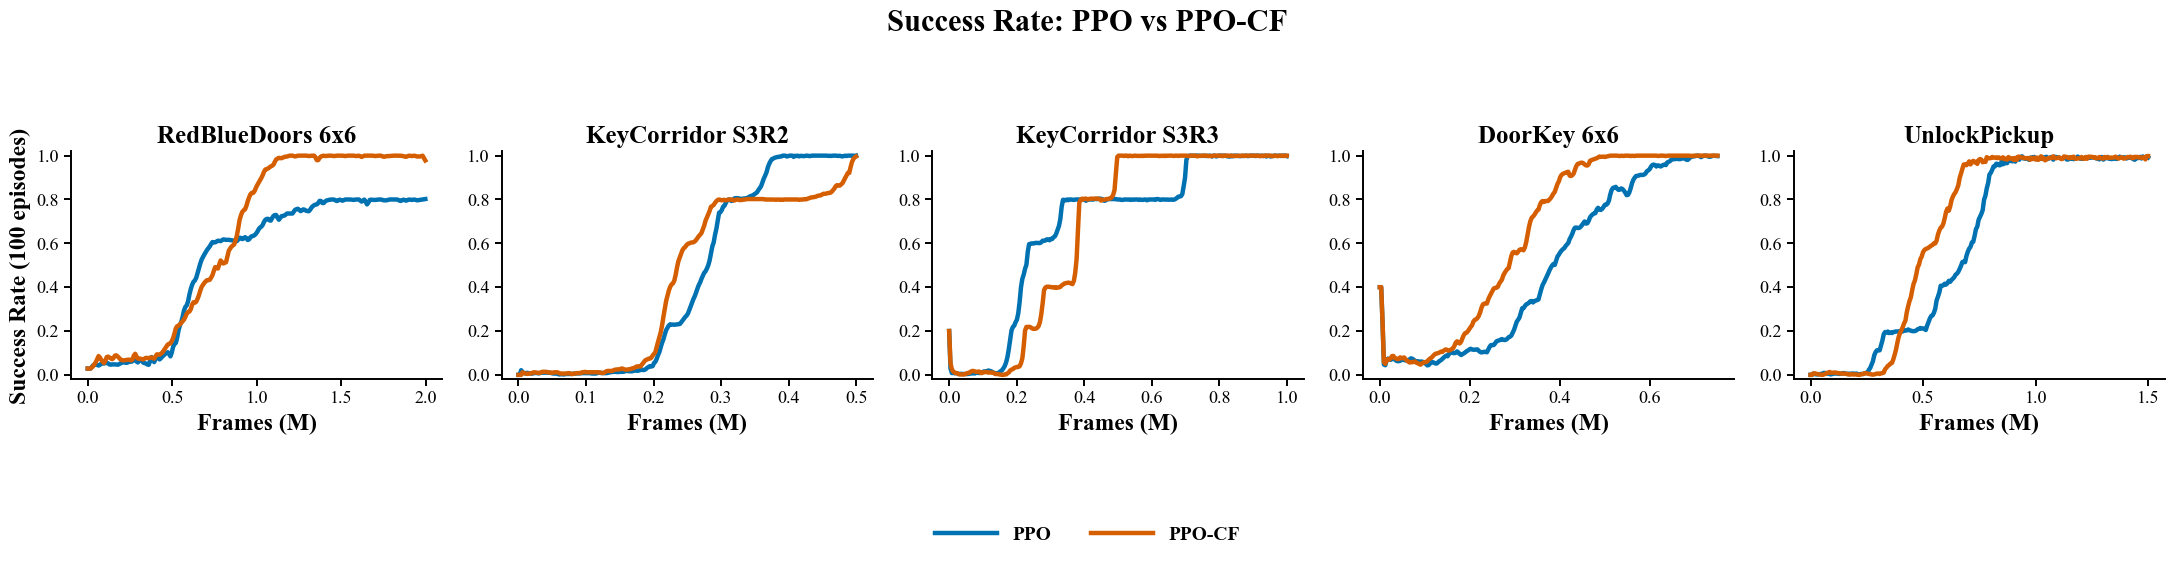

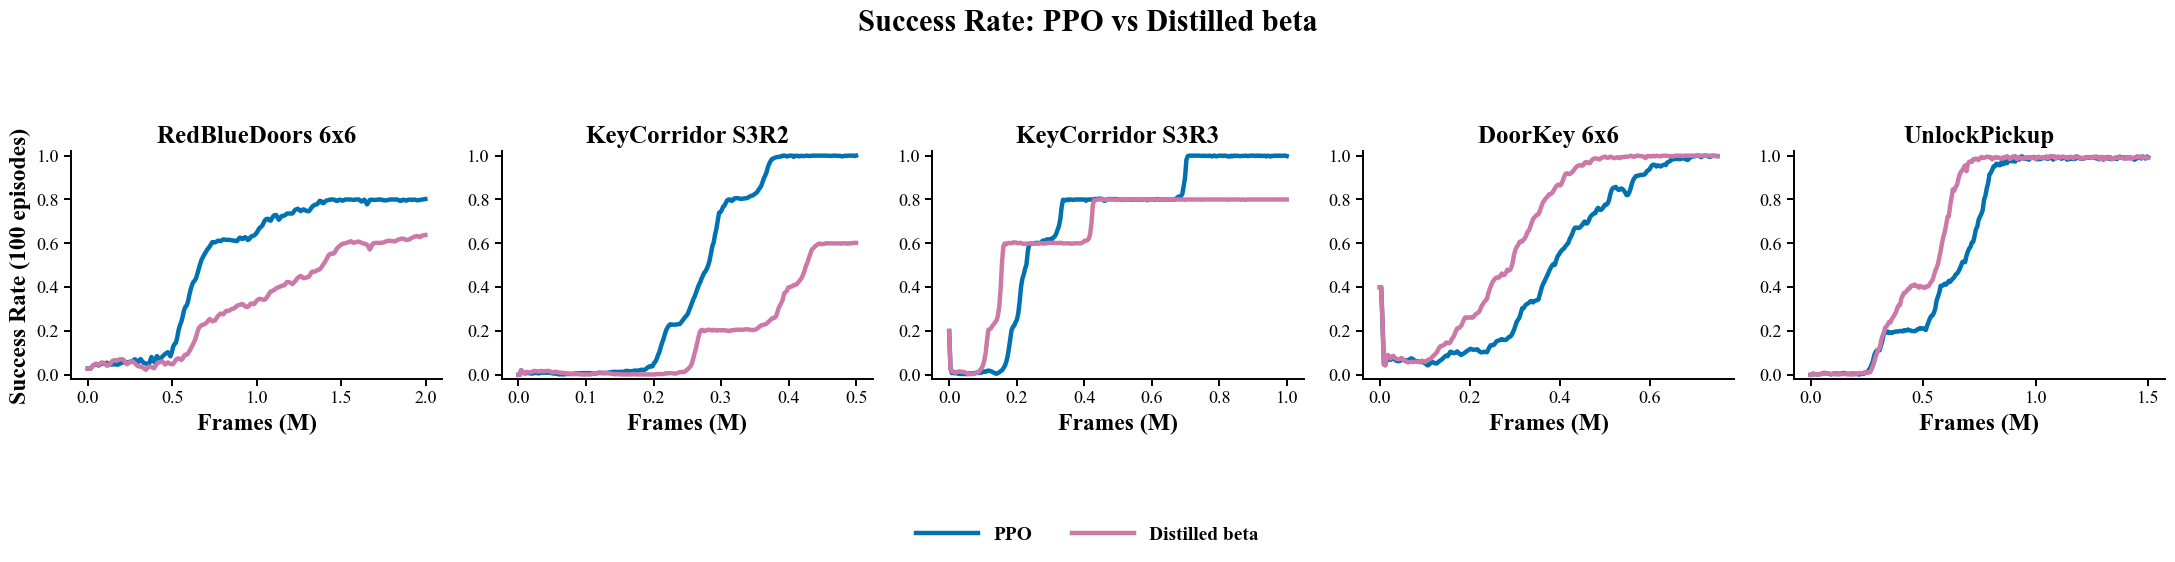

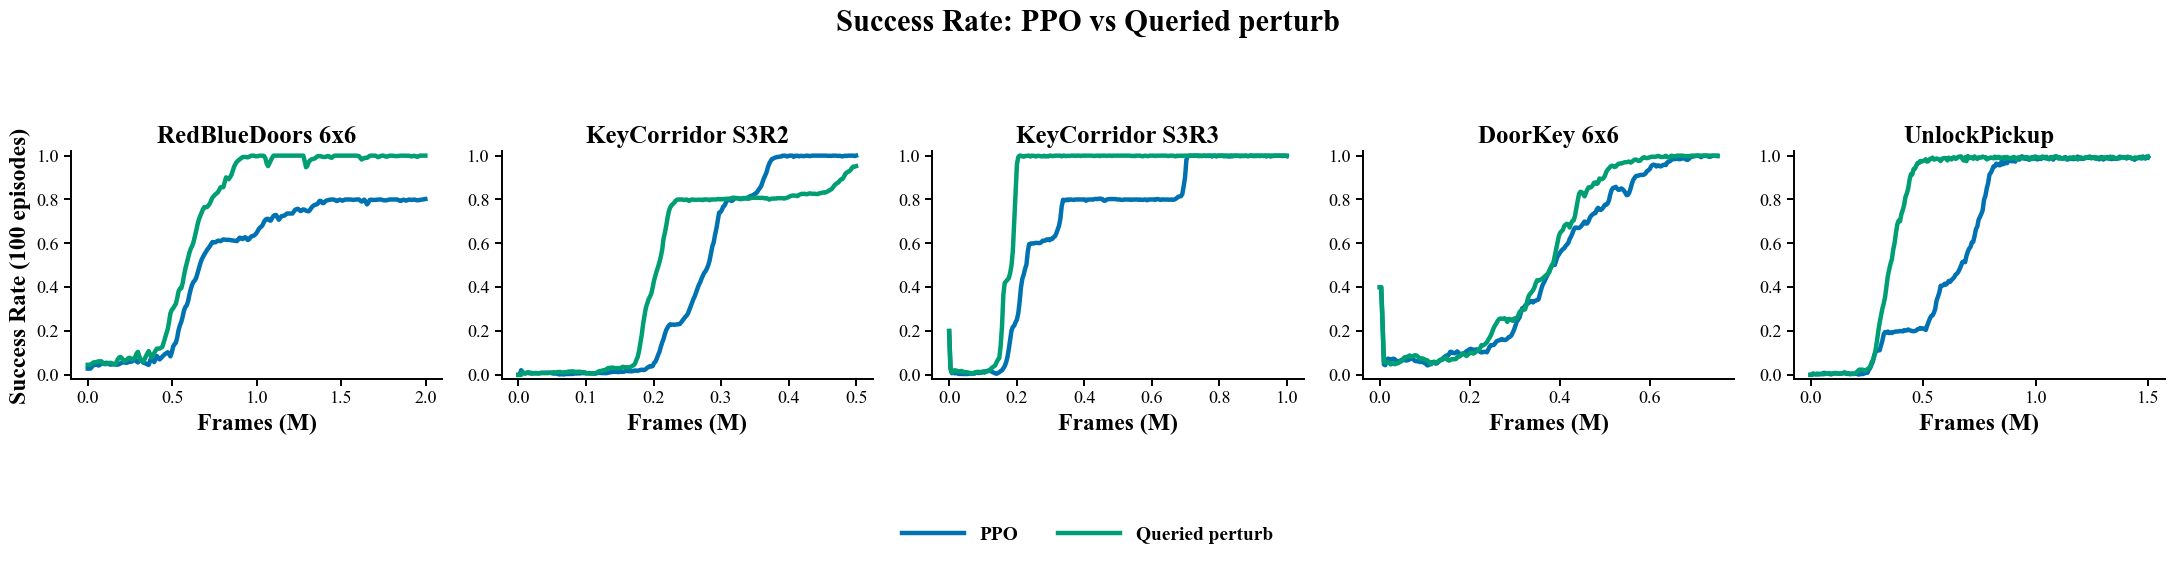

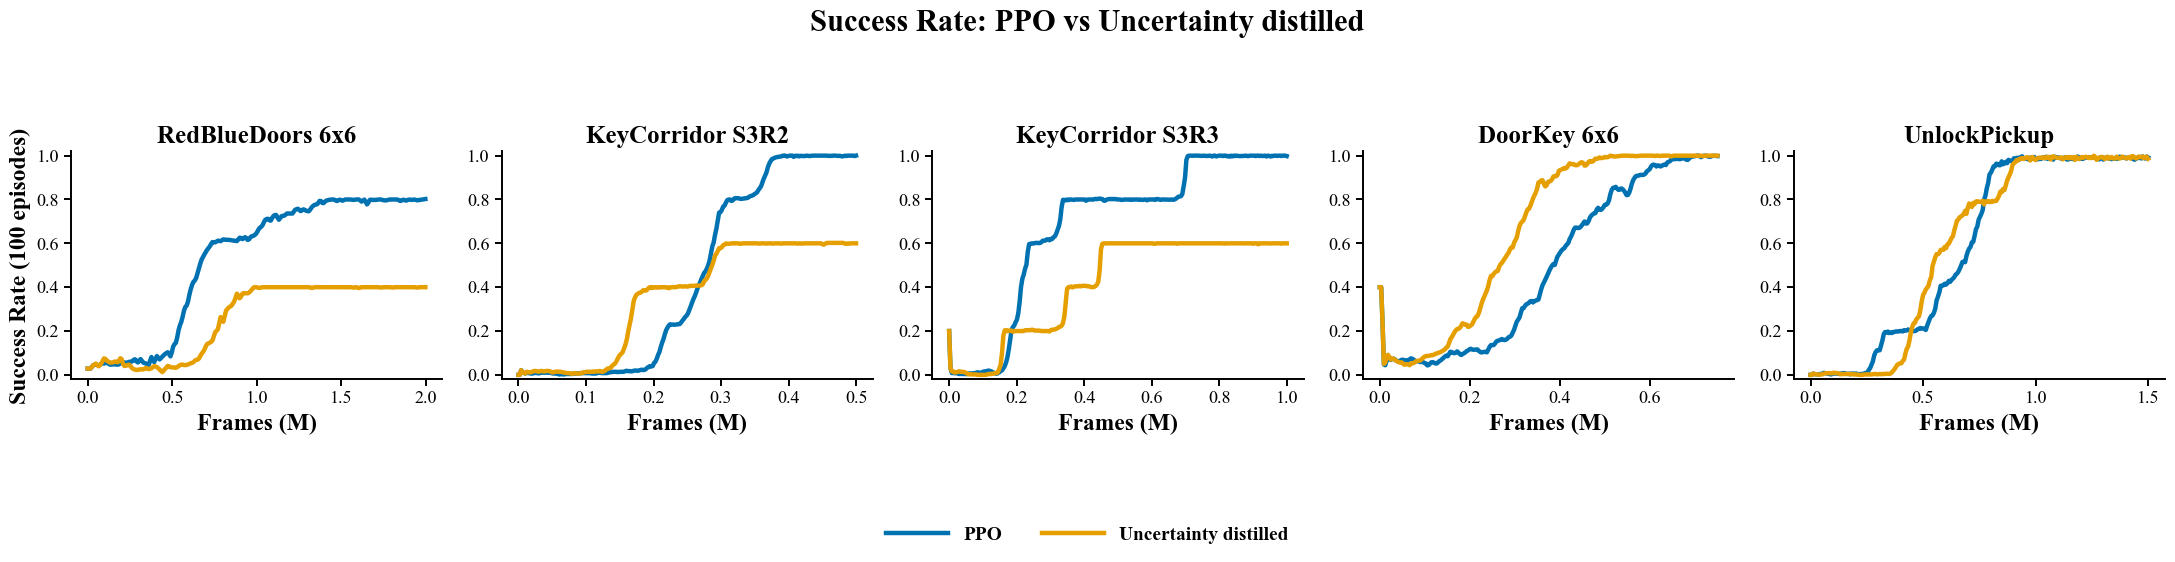

In [10]:
# Matching success-rate comparisons for the same three PPO baselines.
pairwise_success_outputs = [
    plot_pairwise_metric(comparison, "success_rate_100", "Success Rate (100 episodes)", "Success Rate", ylim=(-0.02, 1.02))
    for comparison in PAIRWISE_COMPARISONS
]
for _, png, pdf in pairwise_success_outputs:
    print(png.relative_to(PROJECT_ROOT))
    print(pdf.relative_to(PROJECT_ROOT))